# Mounting Google Drive


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
cd drive/MyDrive

[Errno 2] No such file or directory: 'drive/MyDrive'
/content/drive/MyDrive/Lung_Cancer_Detection


In [8]:
cd Lung_Cancer_Detection/

[Errno 2] No such file or directory: 'Lung_Cancer_Detection/'
/content/drive/MyDrive/Lung_Cancer_Detection


In [9]:
!ls

'archive (1).zip'   CT-Scan_Binary_Classification_Dataset


In [10]:
cd CT-Scan_Binary_Classification_Dataset/

/content/drive/My Drive/Lung_Cancer_Detection/CT-Scan_Binary_Classification_Dataset


# Importing Required Libraries

Importing the necessary libraries for data loading, visualization, and deep learning.

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (confusion_matrix,
    classification_report, roc_curve,
    roc_auc_score, precision_score,
    recall_score, f1_score)

from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, DenseNet121, ResNet50

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D)

# Defining Dataset Path

In [12]:
DATASET_PATH = "/content/drive/MyDrive/Lung_Cancer_Detection/CT-Scan_Binary_Classification_Dataset"

# Creating Training Dataset

80% of the images are used for training.

In [13]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

Found 1097 files belonging to 2 classes.
Using 878 files for training.


# Creating Validation and Test Dataset

The remaining 20% is divided equally into validation and test sets.

In [14]:
temp_ds = tf.keras.utils.image_dataset_from_directory(DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

Found 1097 files belonging to 2 classes.
Using 219 files for validation.


In [15]:
# Spliting Validation Dataset into Validation and Test Sets
val_batches = tf.data.experimental.cardinality(temp_ds)
val_ds = temp_ds.take(val_batches // 2)
test_ds = temp_ds.skip(val_batches // 2)

In [16]:
# Displaying Class Names
class_names = train_ds.class_names

print(class_names)

['Negative', 'Positive']


# Sample Images

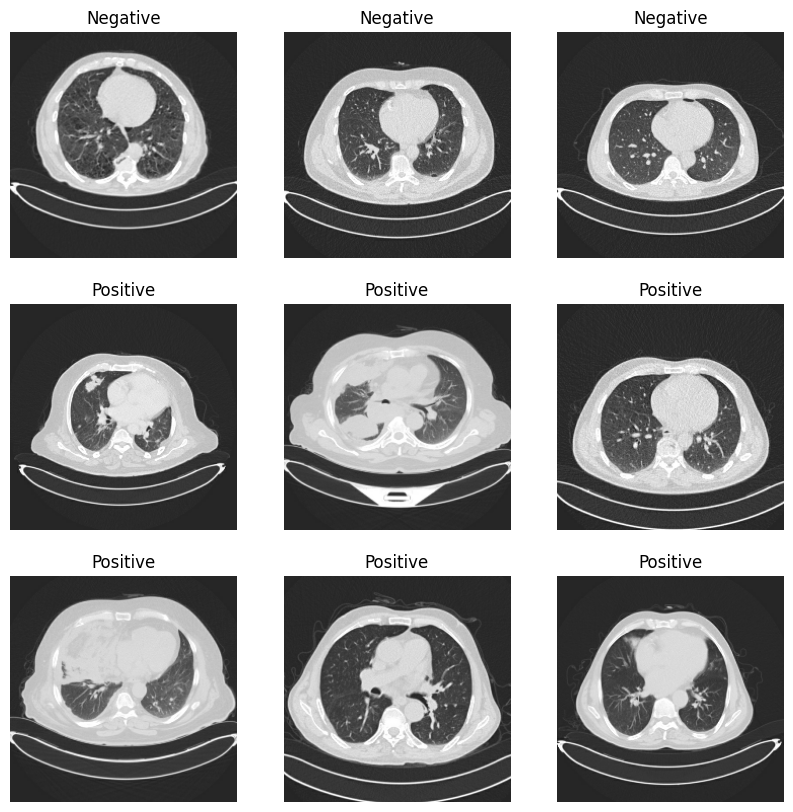

In [17]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# Data Augmentation

Apply random transformations to increase dataset diversity and reduce overfitting.

In [18]:
data_augmentation = tf.keras.Sequential([tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)])

In [19]:
# Normalizing Pixel Values
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Preparing Dataset Pipeline

In [20]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalization_layer(
            data_augmentation(x)), y))


val_ds = val_ds.map(lambda x, y: (
        normalization_layer(x), y))


test_ds = test_ds.map(lambda x, y: (
        normalization_layer(x), y))

In [21]:
# Improving Input Pipeline Performance

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [22]:
results = []

# Defining Training and Validation Block For Models


In [23]:
def train_evaluate_model(model_name, base_model):

    print("="*60)
    print(f"Training {model_name}")
    print("="*60)

    # Freeze base model
    base_model.trainable = False

    # Build model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation ='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    # Compile
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Callbacks
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
        restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
        factor=0.2,
        patience=3,
        verbose=1)
    checkpoint = tf.keras.callbacks.ModelCheckpoint(f"{model_name}.keras", save_best_only=True)

    # Train
    history = model.fit(train_ds, validation_data=val_ds, epochs=20,
        callbacks=[early_stop, reduce_lr, checkpoint])

    # ==========================
    # Accuracy and Loss Curves
    # ==========================

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train", "Validation"])


    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])

    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train", "Validation"])
    plt.show()

    # ==========================
    # Evaluate
    # ==========================

    loss, accuracy = model.evaluate(test_ds, verbose=0)

    # Predictions
    y_true = np.concatenate([y for x, y in test_ds], axis=0)
    y_prob = model.predict(test_ds)

    y_pred = (y_prob > 0.5
    ).astype(int).flatten()

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # ==========================
    # Confusion Matrix
    # ==========================

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    # ==========================
    # ROC Curve
    # ==========================

    auc_score = roc_auc_score(y_true, y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
    plt.plot([0,1], [0,1], '--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} ROC Curve")

    plt.legend()
    plt.show()

    # Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Store Results
    results.append({"Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc_score})
    print("\nSaved:", model_name)
    return model

# MobileNetV2 Model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training MobileNetV2
Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.7426 - loss: 0.5873 - val_accuracy: 0.8333 - val_loss: 0.3120 - learning_rate: 0.0010
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 532ms/step - accuracy: 0.8679 - loss: 0.3223 - val_accuracy: 0.8438 - val_loss: 0.3640 - learning_rate: 0.0010
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 526ms/step - accuracy: 0.8702 - loss: 0.2894 - val_accuracy: 0.8646 - val_loss: 0.2958 - learning_rate: 0.0010
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 544ms/step - accuracy: 0.8667 - loss: 0.2974 - val_accuracy: 0.8854 - val_loss: 0.2730 - learning_rate: 0.0010
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 486ms/step - accuracy: 0.8895 - loss: 0.2519 - val_accuracy: 0.8854 - val_loss: 0.3172 - learning_rate: 0.0010
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 482ms/step - accuracy: 0.8872 - loss: 0.2462 - val_accuracy: 0.8021 - val_loss: 0.4192 - learning_rate: 0.0010
Epoch 7/20
28/2

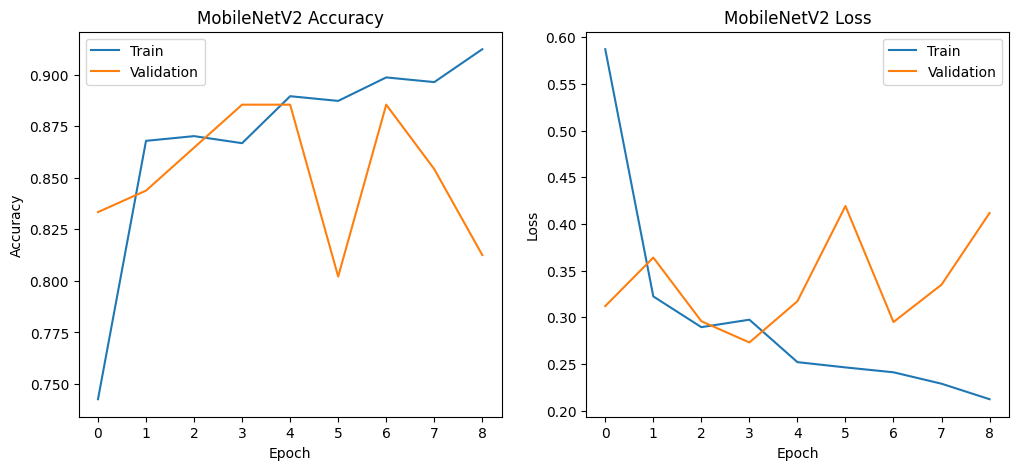

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step

Classification Report:

              precision    recall  f1-score   support

    Negative       0.26      0.35      0.30        40
    Positive       0.63      0.53      0.58        83

    accuracy                           0.47       123
   macro avg       0.45      0.44      0.44       123
weighted avg       0.51      0.47      0.49       123



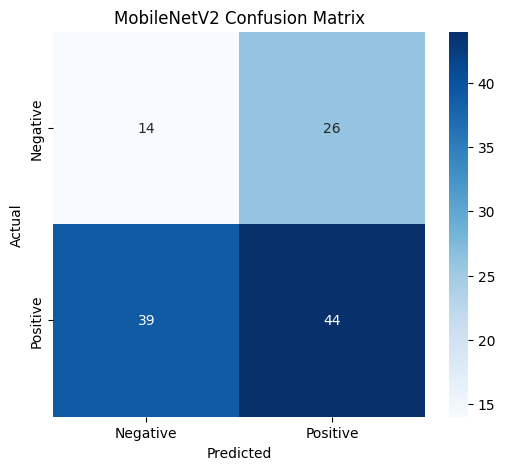

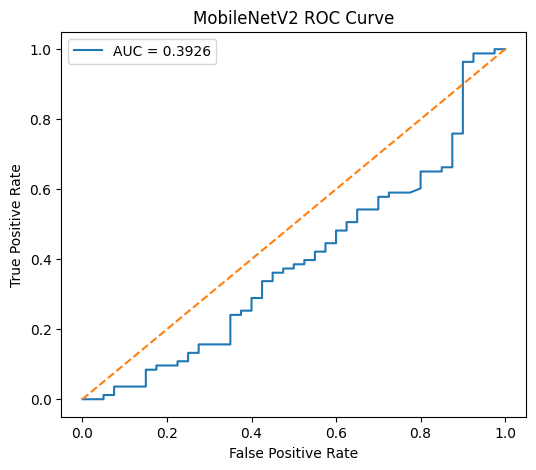


Saved: MobileNetV2


In [24]:
mobilenet_model = train_evaluate_model("MobileNetV2",
    MobileNetV2(weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)))

# EfficientNetB0 Model

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training EfficientNetB0
Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.5843 - loss: 0.6974 - val_accuracy: 0.6042 - val_loss: 0.6719 - learning_rate: 0.0010
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 533ms/step - accuracy: 0.5900 - loss: 0.6868 - val_accuracy: 0.6771 - val_loss: 0.6383 - learning_rate: 0.0010
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 526ms/step - accuracy: 0.5979 - loss: 0.6744 - val_accuracy: 0.6771 - val_loss: 0.6323 - learning_rate: 0.0010
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 492ms/step - accuracy: 0.6128 - loss: 0.6759 - val_accuracy: 0.6146 - val_loss: 0.6670 - learning_rate: 0.0010
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 470ms/step - accuracy: 0.6116 - loss: 0.6718 - val_accuracy: 0.6562 - val_loss: 0.6473 - learning_rate: 0.0010
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.6104 - loss: 0.6719
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.


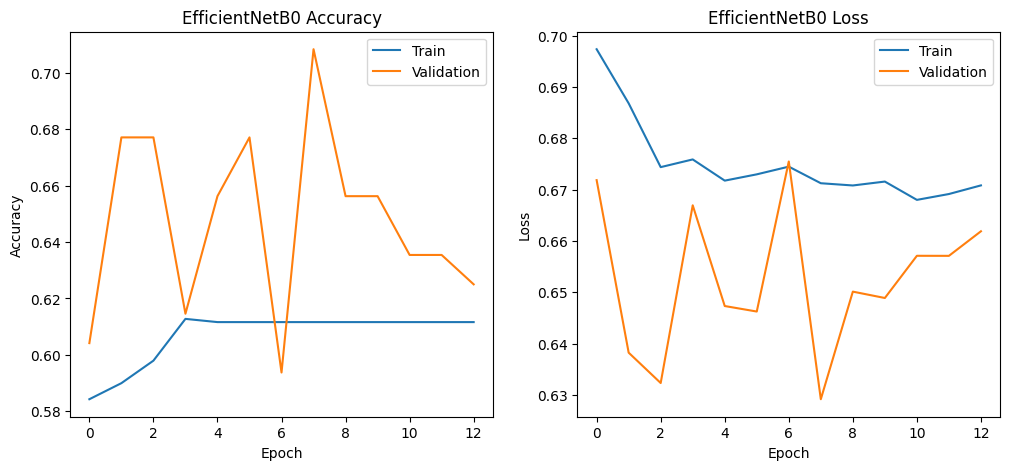

4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step

Classification Report:

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        42
    Positive       0.66      1.00      0.79        81

    accuracy                           0.66       123
   macro avg       0.33      0.50      0.40       123
weighted avg       0.43      0.66      0.52       123



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


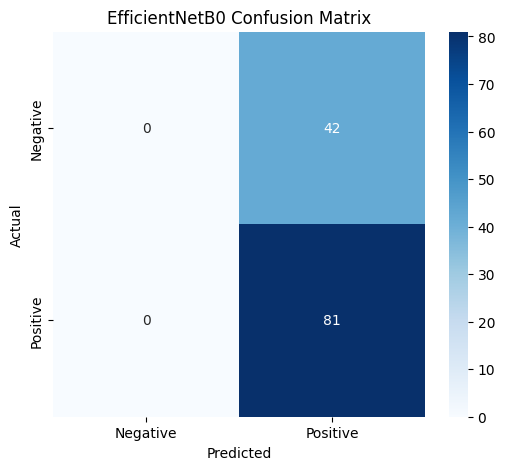

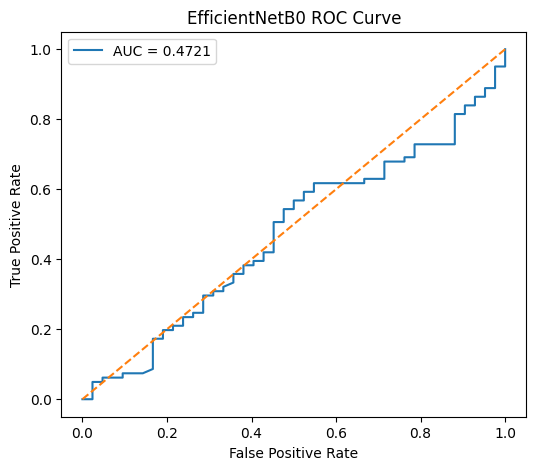


Saved: EfficientNetB0


In [25]:
efficientnet_model = train_evaluate_model(
    "EfficientNetB0",
    EfficientNetB0(weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)))

# DenseNet121 Model

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training DenseNet121
Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.7267 - loss: 0.5479 - val_accuracy: 0.8333 - val_loss: 0.3064 - learning_rate: 0.0010
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 521ms/step - accuracy: 0.8007 - loss: 0.4489 - val_accuracy: 0.8021 - val_loss: 0.4624 - learning_rate: 0.0010
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 594ms/step - accuracy: 0.8394 - loss: 0.3587 - val_accuracy: 0.8854 - val_loss: 0.2362 - learning_rate: 0.0010
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 510ms/step - accuracy: 0.8474 - loss: 0.3277 - val_accuracy: 0.8125 - val_loss: 0.4500 - learning_rate: 0.0010
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 507ms/step - accuracy: 0.8394 - loss: 0.3364 - val_accuracy: 0.8646 - val_loss: 0.3287 - learning_rate: 0.0010
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.8690 - loss: 0.3047
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
28/

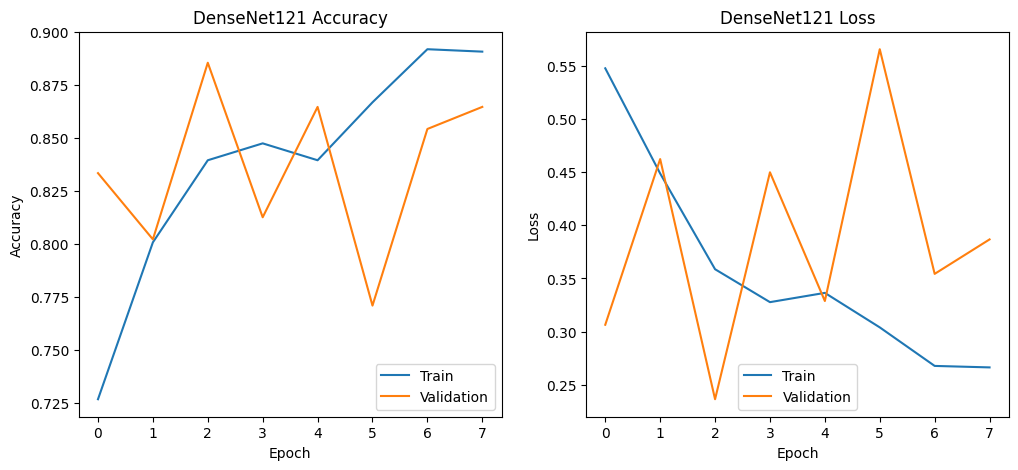

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step

Classification Report:

              precision    recall  f1-score   support

    Negative       0.43      0.46      0.44        46
    Positive       0.66      0.64      0.65        77

    accuracy                           0.57       123
   macro avg       0.55      0.55      0.55       123
weighted avg       0.57      0.57      0.57       123



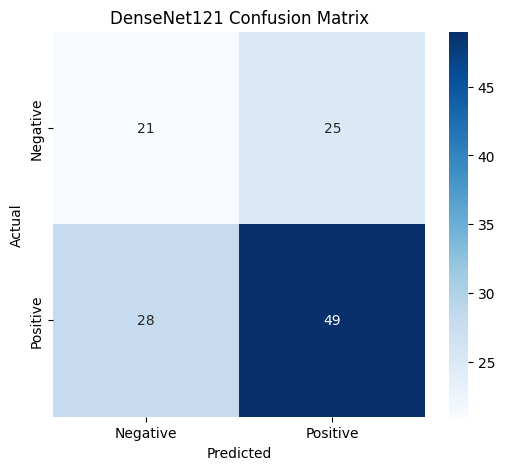

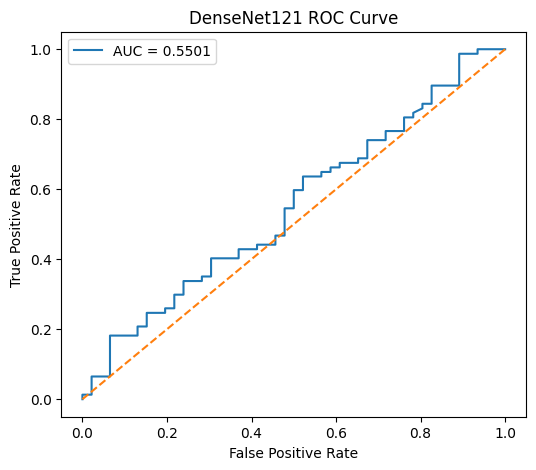


Saved: DenseNet121


In [26]:
densenet_model = train_evaluate_model(
    "DenseNet121",
    DenseNet121(weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)))

# ResNet50 Model

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training ResNet50
Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 40s 920ms/step - accuracy: 0.5877 - loss: 0.7367 - val_accuracy: 0.6458 - val_loss: 0.6193 - learning_rate: 0.0010
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 525ms/step - accuracy: 0.6276 - loss: 0.6457 - val_accuracy: 0.6354 - val_loss: 0.6268 - learning_rate: 0.0010
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 527ms/step - accuracy: 0.6196 - loss: 0.6405 - val_accuracy: 0.5938 - val_loss: 0.6621 - learning_rate: 0.0010
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 560ms/step - accuracy: 0.6367 - loss: 0.6335 - val_accuracy: 0.6458 - val_loss: 0.6043 - learning_rate: 0.0010
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 547ms/step - accuracy: 0.6412 - loss: 0.6211 - val_accuracy: 0.6146 - val_loss: 0.6125 - learning_rate: 0.0010
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 576ms/step - accuracy: 0.6412 - loss: 0.6215 - val_accuracy: 0.7396 - val_loss: 0.5818 - learning_rate: 0.0010
Epoch 7/20
28

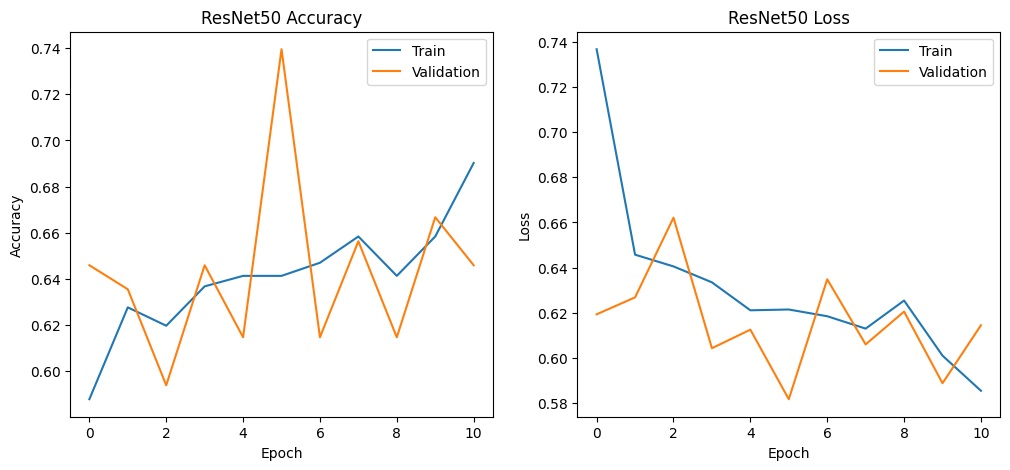

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

Classification Report:

              precision    recall  f1-score   support

    Negative       0.35      0.64      0.45        39
    Positive       0.73      0.45      0.56        84

    accuracy                           0.51       123
   macro avg       0.54      0.55      0.51       123
weighted avg       0.61      0.51      0.53       123



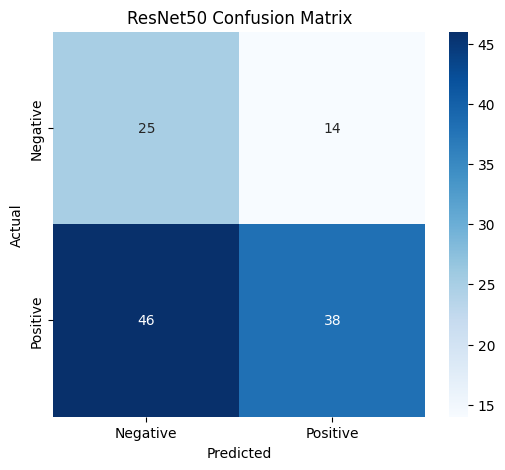

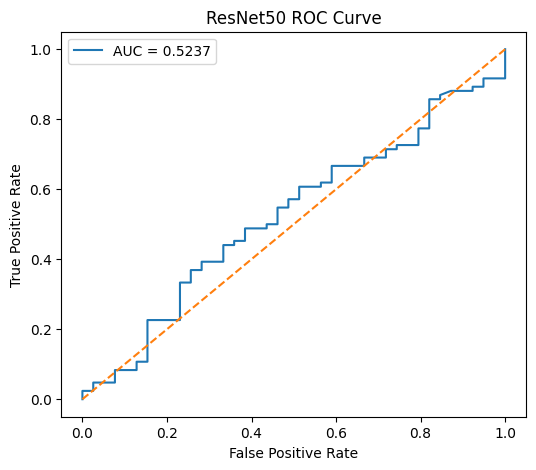


Saved: ResNet50


In [27]:
resnet_model = train_evaluate_model(
    "ResNet50",
    ResNet50(weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)))

# Final Comparison Table

In [29]:
import pandas as pd
results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,MobileNetV2,0.886179,0.628571,0.530120,0.575163,0.392620
2,DenseNet121,0.829268,0.662162,0.636364,0.649007,0.550113
3,ResNet50,0.642276,0.730769,0.452381,0.558824,0.523657
1,EfficientNetB0,0.634146,0.658537,1.000000,0.794118,0.472075


In [30]:
best_model_name = results_df.iloc[0]["Model"]

print(
    "Best Model:",
    best_model_name
)

Best Model: MobileNetV2
